## 1. What this notebook computes

This notebook runs the **Rust Kohn-Sham solver** of the repository over its whole
**canonical matrix**: the Kohn-Sham states of the fermion field dirac16complex in
the author's primordial gravitational field, for three particle numbers, five
couplings and five instants of the deflating history (75 ground states), and for
135 states at three temperatures. Then it

- checks that the solver reports all 42 of its own checks as PASS;
- compares every new result with the committed Revision record (the folder
  Revision/kohn_sham/results), number by number, with tolerances that were fixed in
  advance;
- prints the energies and gaps of the ground states along the history;
- draws seven figures: the Kohn-Sham levels along the history, the gaps, the
  Delta-SCF excitation energies, the total energies, the densities, the
  self-consistent potentials and the convergence of the self-consistent loop.

The run takes about two to three minutes on a computer with many processor cores
(longer on a laptop). Everything it writes outside the folder of the figures goes
into the Rust build folder `Revision/kohn_sham/solver/target/textbook_15a`, which
git ignores.

## 2. How to run this notebook

**Step 1. What this notebook does and what it needs.**

Notebook 15a (Running the Rust Kohn-Sham solver over the canonical matrix) is the file
`Revision/textbook/notebooks/15a_canonical_matrix.ipynb` of the repository Dirac_claude.
It builds the Rust Kohn-Sham solver of the repository, runs it over the whole canonical
matrix (75 ground states and 135 thermal states of the Kohn-Sham gas of dirac16complex
along the deflating history), checks that the new results agree with the committed
Revision record within tolerances fixed in advance, and draws the Kohn-Sham levels, the
gaps, the energies, the densities, the self-consistent potentials and the convergence of
the self-consistent loop. The solver writes its raw output (about 6 MB) into the folder
`Revision/kohn_sham/solver/target/textbook_15a`, which git ignores. It needs a computer
with Windows 11, macOS or Linux, an internet connection for the installation, the program
Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5) with these
packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0, matplotlib
3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0 and
nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other packages
run Jupyter, the program that shows and runs notebooks. It also needs Rust (the program
cargo, version 1.91.1 or newer), because it runs the Rust program revision_ks_solver,
which is part of the repository and is built on your computer.

**Step 2. Install Git and Python (once per computer).**

A terminal is the window in which you type commands: on Windows the app Windows
PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux any
terminal (it runs the shell bash). Type every command of this section into a terminal
exactly as printed, one line at a time, and press Enter after each line.

Windows: download Git from https://git-scm.com/download/win and install it with the
default choices. Download Python from https://www.python.org/downloads/ and run the
installer; in its first window tick the box "Add python.exe to PATH" before you click
"Install Now".

macOS: download Python from https://www.python.org/downloads/ and run the installer. Then
open the app Terminal and run this command, which installs Git and the compiler tools:

macOS (zsh):

    xcode-select --install

Linux (Debian or Ubuntu; other distributions have packages of the same names): run these
two commands:

Linux (bash):

    sudo apt update
    sudo apt install git python3 python3-venv

Then close the terminal and open a NEW one (a terminal opened before the installation
does not know the new programs), and check the version of Python; it must print 3.12 or a
higher number:

Windows (PowerShell):

    py -3 --version

macOS (zsh) and Linux (bash):

    python3 --version

If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
3.12 with the following three commands, and in Step 3 type `python3.12` instead of
`python3` in the command that creates the environment:

Linux (bash), only when the version is too low:

    sudo add-apt-repository ppa:deadsnakes/ppa
    sudo apt update
    sudo apt install python3.12 python3.12-venv

**Step 3. Get the repository and install the packages (once per computer).**

The commands below download the repository (about 130 MB; the folder then takes about 400
MB of disk space) into the folder Dirac_claude inside your home folder, create a private
Python environment in the folder dirac-book-env inside your home folder (a private
environment is a folder with its own copy of Python and of the packages, so that nothing
else on your computer is changed), activate it (from then on the commands `python` and
`jupyter` typed in this terminal are those of the environment, and the prompt starts with
(dirac-book-env)), and install the packages at the pinned versions (this downloads about
90 MB and takes a few minutes; the environment takes about 400 MB of disk space). If you
have done this step before, for this or for another notebook, skip it and go to Step 4;
to get the newest version of the repository, run `git pull` in the repository folder
after Step 4.

Windows (PowerShell):

    cd $HOME
    git clone https://github.com/once-ere/Dirac_claude.git
    py -3 -m venv "$HOME\dirac-book-env"
    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

The line with `Set-ExecutionPolicy` allows PowerShell to run the activation script in
this one window only; it changes nothing permanently.

macOS (zsh):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

Linux (bash):

    cd ~
    git clone https://github.com/once-ere/Dirac_claude.git
    python3 -m venv ~/dirac-book-env
    source ~/dirac-book-env/bin/activate
    python -m pip install --upgrade pip
    python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
    python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
    python -m pip install ipykernel==7.1.0 nbconvert==7.16.6

**Step 4. In every new terminal: activate the environment and go into the repository
folder.**

Every later step starts in the repository folder with the environment active. Run these
lines whenever you open a new terminal (they do no harm if the environment is already
active):

Windows (PowerShell):

    Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
    & "$HOME\dirac-book-env\Scripts\Activate.ps1"
    cd "$HOME\Dirac_claude"

macOS (zsh) and Linux (bash):

    source ~/dirac-book-env/bin/activate
    cd ~/Dirac_claude

**Step 5. Install Rust and build the Rust program (Rust once per computer, the build once
per program).**

Windows: download `rustup-init.exe` from https://rustup.rs, run it and accept the default
choices; if it reports that the Visual Studio C++ Build Tools are missing, let it install
them (or install the workload "Desktop development with C++" from
https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run `rustup-init.exe`
again). macOS and Linux: run the command below and accept the default choice (on Linux
first run `sudo apt install build-essential`, which provides the linker that Rust needs).

macOS (zsh) and Linux (bash):

    curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh

Then close the terminal, open a new one, do Step 4 again, and check the version of cargo;
it must print 1.91.1 or a newer version:

Windows, macOS and Linux:

    cargo --version

Build the program with the following command, in the repository folder (the same command
on all three systems):

Windows, macOS and Linux:

    cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml

The first build takes about 1 minute; later builds reuse the result and take a few
seconds. The program is then the file
`Revision/kohn_sham/solver/target/release/revision_ks_solver` (on Windows with the ending
`.exe`). The notebook runs the same build command itself before it uses the program (it
takes a second when the program is up to date), so the notebook also works if you skip
this build; building here first shows any problem with Rust before the notebook starts.

**Step 6. Run the notebook in JupyterLab.**

In the repository folder, with the environment active, run these two lines (the first one
goes into the folder of the notebooks):

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter lab 15a_canonical_matrix.ipynb

JupyterLab opens in your web browser and shows the notebook (if no browser window opens,
copy the address that starts with `http://localhost:8888/lab` from the terminal into the
address bar of your browser). The name at the top right of the notebook must read Python
3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the label to its
left shows `[*]`; when it has finished, the label shows a number. The notebook has
finished when the last code cell shows a number; this takes about 4 minutes on a typical
laptop. Scroll to the end and compare the last printed lines with the lines in the step
"What the notebook writes and what you must see" below. To keep the results, save the
notebook (menu File > Save Notebook). To stop JupyterLab, choose the menu File > Shut
Down, or press Ctrl+C twice in the terminal.

**Step 7. Or run the notebook without a browser (headless).**

In the repository folder, with the environment active, run:

Windows, macOS and Linux:

    cd Revision/textbook/notebooks
    jupyter nbconvert --to notebook --execute --inplace 15a_canonical_matrix.ipynb

This runs every cell from the top to the bottom and saves the results into the notebook
file. A failed check stops it with an error message that contains AssertionError and the
name of the check. If the command ends with a line that starts with `[NbConvertApp]
Writing` and shows no error, every check passed; open the notebook with `jupyter lab
15a_canonical_matrix.ipynb` (in the same folder, without running the cells again) to read
the printed lines and see the figures.

**Step 8. What the notebook writes and what you must see.**

The notebook writes (or overwrites) these files:

- `Revision/textbook/figures/15a.captions.json`
- `Revision/textbook/figures/15a_1_levels_history.png`
- `Revision/textbook/figures/15a_2_gaps_history.png`
- `Revision/textbook/figures/15a_3_delta_scf.png`
- `Revision/textbook/figures/15a_4_energy_history.png`
- `Revision/textbook/figures/15a_5_densities.png`
- `Revision/textbook/figures/15a_6_potentials.png`
- `Revision/textbook/figures/15a_7_scf_convergence.png`

It changes no other file of the repository except the Rust build folder `target` next to
each `Cargo.toml` it builds; running it headless or saving it in JupyterLab also rewrites
the notebook file itself. It does not use the internet while it runs. The files it writes
are the same files that are stored in the repository (on another computer a figure may
differ in a few bytes, which is harmless). To get the stored versions back, run this
command in the repository folder (it also undoes every change you made yourself in the
folder Revision/textbook):

Windows, macOS and Linux:

    git checkout -- Revision/textbook

Every check of the notebook prints a line that starts with PASS. At the end of the
notebook (the output of its last code cell) you must see exactly these lines:

    PASS every figure file of this notebook exists
    ALL 20 CHECKS PASSED (notebook 15a)

and the notebook must show 7 figures below the cells that draw them.

**Step 9. If something goes wrong.**

- "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
  without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
  again. If the error remains, another Python installation has registered its own kernel
  called python3; with the environment active, run the following command and start
  JupyterLab again:

      python -m ipykernel install --user --name python3

- "FileNotFoundError: The repository folder was not found": the notebook was opened from
  a copy outside the repository. Open the file
  `Revision/textbook/notebooks/15a_canonical_matrix.ipynb` inside the folder
  Dirac_claude.
- "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
  downloaded before; skip the line with `git clone`.
- Windows: "running scripts is disabled on this system": run the line with
  `Set-ExecutionPolicy` and then the activation line again. "py is not recognized": use
  `python` instead of `py -3`; "python is not recognized": install Python again and tick
  "Add python.exe to PATH".
- Linux: "ensurepip is not available" when the environment is created: run `sudo apt
  install python3-venv` and repeat Step 3.
- "jupyter is not recognized" or "command not found: jupyter": the environment is not
  active; do Step 4 (or type `python -m jupyter` instead of `jupyter`).
- Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
  loop" and zmq: this is a message of the package pyzmq, not an error; the run continues
  normally.
- A red box with "Matplotlib is building the font cache; this may take a moment." in the
  first run after the installation: this is a message, not an error; the run continues
  and the message does not come again.
- An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
  and Run All Cells; if it fails again, install the packages again with the pip commands
  of Step 3, because a different package version can change the last digits of a result.
- "cargo is not recognized" or "command not found: cargo" or "cargo was not found": open
  a new terminal after installing Rust, do Step 4 again, and start JupyterLab from this
  terminal.
- "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the C++
  Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
  again.
- The cell that runs the canonical matrix shows the label with the star for several
  minutes: this is normal. The solver computes 210 states and uses up to 22 processor
  cores; on a computer with 4 cores it needs about 10 minutes. Wait until the label shows
  a number.
- An AssertionError names one of the comparisons with the record: the notebook prints the
  largest difference just above the error. Differences far below the tolerance are
  rounding effects of another computer; a larger difference means that the solver or its
  input files were changed. Get the stored versions back and run the notebook again.

      git checkout -- Revision/kohn_sham

- You want the disk space of the solver output back: the folder
  `Revision/kohn_sham/solver/target/textbook_15a` holds only the raw output of the last
  run (ignored by git); delete it at any time, the notebook writes it again.

The first code cell below (the set-up cell) repeats these instructions as comments; then
it imports the packages, finds the repository folder and defines the helpers
`save_figure` (saves a figure and shows it), `check` (stops with an AssertionError when a
check fails, prints a PASS line when it passes), `report` (prints a key number as a
RESULT line) and `all_checks_passed` (prints the last line).

In [1]:
# HOW TO RUN NOTEBOOK 15a (the complete instructions)
#
# STEP 1. WHAT THIS NOTEBOOK DOES AND WHAT IT NEEDS.
#
# Notebook 15a (Running the Rust Kohn-Sham solver over the canonical matrix) is the file
# Revision/textbook/notebooks/15a_canonical_matrix.ipynb of the repository Dirac_claude.
# It builds the Rust Kohn-Sham solver of the repository, runs it over the whole canonical
# matrix (75 ground states and 135 thermal states of the Kohn-Sham gas of dirac16complex
# along the deflating history), checks that the new results agree with the committed
# Revision record within tolerances fixed in advance, and draws the Kohn-Sham levels, the
# gaps, the energies, the densities, the self-consistent potentials and the convergence
# of the self-consistent loop. The solver writes its raw output (about 6 MB) into the
# folder Revision/kohn_sham/solver/target/textbook_15a, which git ignores. It needs a
# computer with Windows 11, macOS or Linux, an internet connection for the installation,
# the program Git, and Python 3.12 or newer (the notebooks were built with Python 3.14.5)
# with these packages at exactly these versions: numpy 2.4.6, sympy 1.14.0, mpmath 1.3.0,
# matplotlib 3.11.0, jupyterlab 4.4.10, nbformat 5.10.4, nbclient 0.10.2, ipykernel 7.1.0
# and nbconvert 7.16.6. The notebook itself imports numpy and matplotlib; the other
# packages run Jupyter, the program that shows and runs notebooks. It also needs Rust
# (the program cargo, version 1.91.1 or newer), because it runs the Rust program
# revision_ks_solver, which is part of the repository and is built on your computer.
#
# STEP 2. INSTALL GIT AND PYTHON (ONCE PER COMPUTER).
#
# A terminal is the window in which you type commands: on Windows the app Windows
# PowerShell (or Terminal), on macOS the app Terminal (it runs the shell zsh), on Linux
# any terminal (it runs the shell bash). Type every command of this section into a
# terminal exactly as printed, one line at a time, and press Enter after each line.
#
# Windows: download Git from https://git-scm.com/download/win and install it with the
# default choices. Download Python from https://www.python.org/downloads/ and run the
# installer; in its first window tick the box "Add python.exe to PATH" before you click
# "Install Now".
#
# macOS: download Python from https://www.python.org/downloads/ and run the installer.
# Then open the app Terminal and run this command, which installs Git and the compiler
# tools:
#
# macOS (zsh):
#     xcode-select --install
#
# Linux (Debian or Ubuntu; other distributions have packages of the same names): run
# these two commands:
#
# Linux (bash):
#     sudo apt update
#     sudo apt install git python3 python3-venv
#
# Then close the terminal and open a NEW one (a terminal opened before the installation
# does not know the new programs), and check the version of Python; it must print 3.12 or
# a higher number:
#
# Windows (PowerShell):
#     py -3 --version
#
# macOS (zsh) and Linux (bash):
#     python3 --version
#
# If an older Linux prints a lower number (Ubuntu 22.04 has Python 3.10), install Python
# 3.12 with the following three commands, and in Step 3 type python3.12 instead of
# python3 in the command that creates the environment:
#
# Linux (bash), only when the version is too low:
#     sudo add-apt-repository ppa:deadsnakes/ppa
#     sudo apt update
#     sudo apt install python3.12 python3.12-venv
#
# STEP 3. GET THE REPOSITORY AND INSTALL THE PACKAGES (ONCE PER COMPUTER).
#
# The commands below download the repository (about 130 MB; the folder then takes about
# 400 MB of disk space) into the folder Dirac_claude inside your home folder, create a
# private Python environment in the folder dirac-book-env inside your home folder (a
# private environment is a folder with its own copy of Python and of the packages, so
# that nothing else on your computer is changed), activate it (from then on the commands
# python and jupyter typed in this terminal are those of the environment, and the prompt
# starts with (dirac-book-env)), and install the packages at the pinned versions (this
# downloads about 90 MB and takes a few minutes; the environment takes about 400 MB of
# disk space). If you have done this step before, for this or for another notebook, skip
# it and go to Step 4; to get the newest version of the repository, run git pull in the
# repository folder after Step 4.
#
# Windows (PowerShell):
#     cd $HOME
#     git clone https://github.com/once-ere/Dirac_claude.git
#     py -3 -m venv "$HOME\dirac-book-env"
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# The line with Set-ExecutionPolicy allows PowerShell to run the activation script in
# this one window only; it changes nothing permanently.
#
# macOS (zsh):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# Linux (bash):
#     cd ~
#     git clone https://github.com/once-ere/Dirac_claude.git
#     python3 -m venv ~/dirac-book-env
#     source ~/dirac-book-env/bin/activate
#     python -m pip install --upgrade pip
#     python -m pip install numpy==2.4.6 sympy==1.14.0 mpmath==1.3.0 matplotlib==3.11.0
#     python -m pip install jupyterlab==4.4.10 nbformat==5.10.4 nbclient==0.10.2
#     python -m pip install ipykernel==7.1.0 nbconvert==7.16.6
#
# STEP 4. IN EVERY NEW TERMINAL: ACTIVATE THE ENVIRONMENT AND GO INTO THE REPOSITORY
# FOLDER.
#
# Every later step starts in the repository folder with the environment active. Run these
# lines whenever you open a new terminal (they do no harm if the environment is already
# active):
#
# Windows (PowerShell):
#     Set-ExecutionPolicy -ExecutionPolicy RemoteSigned -Scope Process -Force
#     & "$HOME\dirac-book-env\Scripts\Activate.ps1"
#     cd "$HOME\Dirac_claude"
#
# macOS (zsh) and Linux (bash):
#     source ~/dirac-book-env/bin/activate
#     cd ~/Dirac_claude
#
# STEP 5. INSTALL RUST AND BUILD THE RUST PROGRAM (RUST ONCE PER COMPUTER, THE BUILD ONCE
# PER PROGRAM).
#
# Windows: download rustup-init.exe from https://rustup.rs, run it and accept the default
# choices; if it reports that the Visual Studio C++ Build Tools are missing, let it
# install them (or install the workload "Desktop development with C++" from
# https://visualstudio.microsoft.com/visual-cpp-build-tools/ and run rustup-init.exe
# again). macOS and Linux: run the command below and accept the default choice (on Linux
# first run sudo apt install build-essential, which provides the linker that Rust needs).
#
# macOS (zsh) and Linux (bash):
#     curl --proto "=https" --tlsv1.2 -sSf https://sh.rustup.rs | sh
#
# Then close the terminal, open a new one, do Step 4 again, and check the version of
# cargo; it must print 1.91.1 or a newer version:
#
# Windows, macOS and Linux:
#     cargo --version
#
# Build the program with the following command, in the repository folder (the same
# command on all three systems):
#
# Windows, macOS and Linux:
#     cargo build --release --manifest-path Revision/kohn_sham/solver/Cargo.toml
#
# The first build takes about 1 minute; later builds reuse the result and take a few
# seconds. The program is then the file
# Revision/kohn_sham/solver/target/release/revision_ks_solver (on Windows with the ending
# .exe). The notebook runs the same build command itself before it uses the program (it
# takes a second when the program is up to date), so the notebook also works if you skip
# this build; building here first shows any problem with Rust before the notebook starts.
#
# STEP 6. RUN THE NOTEBOOK IN JUPYTERLAB.
#
# In the repository folder, with the environment active, run these two lines (the first
# one goes into the folder of the notebooks):
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter lab 15a_canonical_matrix.ipynb
#
# JupyterLab opens in your web browser and shows the notebook (if no browser window
# opens, copy the address that starts with http://localhost:8888/lab from the terminal
# into the address bar of your browser). The name at the top right of the notebook must
# read Python 3 (ipykernel). Choose the menu Run > Run All Cells. While a cell runs, the
# label to its left shows [*]; when it has finished, the label shows a number. The
# notebook has finished when the last code cell shows a number; this takes about 4
# minutes on a typical laptop. Scroll to the end and compare the last printed lines with
# the lines in the step "What the notebook writes and what you must see" below. To keep
# the results, save the notebook (menu File > Save Notebook). To stop JupyterLab, choose
# the menu File > Shut Down, or press Ctrl+C twice in the terminal.
#
# STEP 7. OR RUN THE NOTEBOOK WITHOUT A BROWSER (HEADLESS).
#
# In the repository folder, with the environment active, run:
#
# Windows, macOS and Linux:
#     cd Revision/textbook/notebooks
#     jupyter nbconvert --to notebook --execute --inplace 15a_canonical_matrix.ipynb
#
# This runs every cell from the top to the bottom and saves the results into the notebook
# file. A failed check stops it with an error message that contains AssertionError and
# the name of the check. If the command ends with a line that starts with [NbConvertApp]
# Writing and shows no error, every check passed; open the notebook with jupyter lab
# 15a_canonical_matrix.ipynb (in the same folder, without running the cells again) to
# read the printed lines and see the figures.
#
# STEP 8. WHAT THE NOTEBOOK WRITES AND WHAT YOU MUST SEE.
#
# The notebook writes (or overwrites) these files:
#
# - Revision/textbook/figures/15a.captions.json
# - Revision/textbook/figures/15a_1_levels_history.png
# - Revision/textbook/figures/15a_2_gaps_history.png
# - Revision/textbook/figures/15a_3_delta_scf.png
# - Revision/textbook/figures/15a_4_energy_history.png
# - Revision/textbook/figures/15a_5_densities.png
# - Revision/textbook/figures/15a_6_potentials.png
# - Revision/textbook/figures/15a_7_scf_convergence.png
#
# It changes no other file of the repository except the Rust build folder target next to
# each Cargo.toml it builds; running it headless or saving it in JupyterLab also rewrites
# the notebook file itself. It does not use the internet while it runs. The files it
# writes are the same files that are stored in the repository (on another computer a
# figure may differ in a few bytes, which is harmless). To get the stored versions back,
# run this command in the repository folder (it also undoes every change you made
# yourself in the folder Revision/textbook):
#
# Windows, macOS and Linux:
#     git checkout -- Revision/textbook
#
# Every check of the notebook prints a line that starts with PASS. At the end of the
# notebook (the output of its last code cell) you must see exactly these lines:
#
#     PASS every figure file of this notebook exists
#     ALL 20 CHECKS PASSED (notebook 15a)
#
# and the notebook must show 7 figures below the cells that draw them.
#
# STEP 9. IF SOMETHING GOES WRONG.
#
# - "ModuleNotFoundError: No module named ..." in the notebook: JupyterLab was started
#   without the environment. Stop it (menu File > Shut Down), do Step 4, and start it
#   again. If the error remains, another Python installation has registered its own
#   kernel called python3; with the environment active, run the following command and
#   start JupyterLab again:
#     python -m ipykernel install --user --name python3
# - "FileNotFoundError: The repository folder was not found": the notebook was opened
#   from a copy outside the repository. Open the file
#   Revision/textbook/notebooks/15a_canonical_matrix.ipynb inside the folder
#   Dirac_claude.
# - "fatal: destination path 'Dirac_claude' already exists" in Step 3: the repository was
#   downloaded before; skip the line with git clone.
# - Windows: "running scripts is disabled on this system": run the line with
#   Set-ExecutionPolicy and then the activation line again. "py is not recognized": use
#   python instead of py -3; "python is not recognized": install Python again and tick
#   "Add python.exe to PATH".
# - Linux: "ensurepip is not available" when the environment is created: run sudo apt
#   install python3-venv and repeat Step 3.
# - "jupyter is not recognized" or "command not found: jupyter": the environment is not
#   active; do Step 4 (or type python -m jupyter instead of jupyter).
# - Windows: the headless run prints a RuntimeWarning that mentions the "Proactor event
#   loop" and zmq: this is a message of the package pyzmq, not an error; the run
#   continues normally.
# - A red box with "Matplotlib is building the font cache; this may take a moment." in
#   the first run after the installation: this is a message, not an error; the run
#   continues and the message does not come again.
# - An AssertionError names a check that failed: choose the menu Kernel > Restart Kernel
#   and Run All Cells; if it fails again, install the packages again with the pip
#   commands of Step 3, because a different package version can change the last digits of
#   a result.
# - "cargo is not recognized" or "command not found: cargo" or "cargo was not found":
#   open a new terminal after installing Rust, do Step 4 again, and start JupyterLab from
#   this terminal.
# - "linker link.exe not found" (Windows) or "linker cc not found" (Linux): install the
#   C++ Build Tools (Windows) or build-essential (Linux) as described in Step 5 and build
#   again.
# - The cell that runs the canonical matrix shows the label with the star for several
#   minutes: this is normal. The solver computes 210 states and uses up to 22 processor
#   cores; on a computer with 4 cores it needs about 10 minutes. Wait until the label
#   shows a number.
# - An AssertionError names one of the comparisons with the record: the notebook prints
#   the largest difference just above the error. Differences far below the tolerance are
#   rounding effects of another computer; a larger difference means that the solver or
#   its input files were changed. Get the stored versions back and run the notebook
#   again.
#     git checkout -- Revision/kohn_sham
# - You want the disk space of the solver output back: the folder
#   Revision/kohn_sham/solver/target/textbook_15a holds only the raw output of the last
#   run (ignored by git); delete it at any time, the notebook writes it again.
#
# ---------------------------------------------------------------------------------------
# =======================================================================================
# THE SET-UP (the same in every notebook of this book; it computes no physics)
# =======================================================================================
import json  # reads and writes JSON files (text files that hold names and numbers)
import os  # reads the environment variable TEXTBOOK_OUTPUT_ROOT (explained below)
import textwrap  # breaks long printed text into lines of at most 89 characters
from pathlib import Path  # file and folder paths that work on Windows, macOS and Linux

import matplotlib  # the plotting package
import matplotlib.pyplot as plt  # its drawing functions, called plt by convention
from IPython.display import Image, display  # shows a saved picture below a cell
import shutil  # finds the program cargo
import subprocess  # runs cargo and the Rust programs

NOTEBOOK_ID = "15a"  # this notebook: chapter 15, example a


def find_repository_root():
    """Return the repository folder (Dirac_claude).

    Jupyter runs a notebook in the folder that holds it.  Starting there, go up one
    folder at a time until a folder contains Revision/textbook/requirements.txt (the
    list of the book's packages); that folder is the repository."""
    here = Path.cwd().resolve()  # the folder in which this notebook runs
    for folder in [here, *here.parents]:  # this folder, its parent, its grandparent ...
        if (folder / "Revision" / "textbook" / "requirements.txt").is_file():
            return folder
    raise FileNotFoundError(
        "The repository folder was not found: open this notebook inside the folder "
        "Revision/textbook/notebooks of the repository Dirac_claude")


# The repository folder.  It is never printed: it differs from computer to computer,
# and the printed output of a notebook must not.
REPO = find_repository_root()
# Every file is WRITTEN below OUTPUT_ROOT.  OUTPUT_ROOT is the repository folder unless
# the environment variable TEXTBOOK_OUTPUT_ROOT names another folder; the book's
# checking tool sets it, so that a check run writes into a scratch folder instead.
OUTPUT_ROOT = Path(os.environ.get("TEXTBOOK_OUTPUT_ROOT", str(REPO)))


def repository_file(relative):
    """The path of the repository file relative, for READING (a Revision record)."""
    return REPO / relative


def output_file(relative):
    """The path at which to WRITE the repository file relative (its folder is made)."""
    path = OUTPUT_ROOT / relative
    path.parent.mkdir(parents=True, exist_ok=True)
    return path


def say(text):
    """Print text in lines of at most 89 characters (the width of a page of the book)."""
    print(textwrap.fill(str(text), width=89, subsequent_indent="    "))


matplotlib.rcdefaults()  # ignore personal matplotlib settings: same figures everywhere
plt.rcParams.update({"figure.figsize": (7.0, 4.2), "font.size": 10.0,
                     "axes.grid": True, "grid.alpha": 0.3})

FIGURE_FOLDER = "Revision/textbook/figures"  # where the figures are saved
CAPTION_FILE = f"{FIGURE_FOLDER}/{NOTEBOOK_ID}.captions.json"  # their captions
FIGURE_NUMBERS = {}  # figure name -> its number k (file name <id>_<k>_<name>.png)
CAPTIONS = {}  # figure file name -> caption, written to CAPTION_FILE after every figure
# Start with an empty captions file ({} is an empty JSON dictionary); save_figure fills
# it.  newline="\n" writes the same line ends on Windows, macOS and Linux.
output_file(CAPTION_FILE).write_text("{}\n", encoding="utf-8", newline="\n")


def save_figure(fig, name, caption):
    """Save the figure fig as Revision/textbook/figures/<id>_<k>_<name>.png, record its
    caption in CAPTION_FILE, show the saved picture below the cell and close the figure.
    k counts the figures of the notebook 1, 2, 3, ...; a cell run again keeps its k."""
    number = FIGURE_NUMBERS.setdefault(name, len(FIGURE_NUMBERS) + 1)
    file_name = f"{NOTEBOOK_ID}_{number}_{name}.png"
    relative = f"{FIGURE_FOLDER}/{file_name}"
    # dpi=150: 150 dots per inch.  bbox_inches="tight": cut away the empty margin.
    # metadata={"Software": None}: no program name is stored in the PNG file, so that
    # every run writes exactly the same bytes.
    fig.savefig(output_file(relative), dpi=150, bbox_inches="tight",
                metadata={"Software": None})
    plt.close(fig)  # forget the figure, so that Jupyter does not draw it a second time
    CAPTIONS[file_name] = caption
    output_file(CAPTION_FILE).write_text(
        json.dumps(CAPTIONS, indent=1, sort_keys=True) + "\n", encoding="utf-8",
        newline="\n")
    display(Image(filename=str(output_file(relative))),
            metadata={"textbook_figure": file_name})  # the saved picture itself
    say(f"Figure {NOTEBOOK_ID}.{number} saved as {relative}")


PASSED = []  # the names of the checks that passed, in order


def check(condition, name, record=None):
    """A check.  If condition is False, stop with an AssertionError that names the
    check (an if statement is used instead of assert, because python -O would skip an
    assert).  Otherwise print "PASS <name>" and, when the check reproduces a Revision
    record, a second line naming the record file and its check."""
    if not condition:
        raise AssertionError(f"check failed: {name}")
    PASSED.append(name)
    say(f"PASS {name}")
    if record is not None:
        say(f"     reproduces {record}")


def report(label, value, unit=""):
    """Print a key number as a line "RESULT <label> = <value> <unit>"."""
    say(f"RESULT {label} = {value}" + (f" {unit}" if unit else ""))


def all_checks_passed():
    """Print the last line of the notebook: how many checks passed."""
    print(f"ALL {len(PASSED)} CHECKS PASSED (notebook {NOTEBOOK_ID})")


def rust_program(manifest, binary):
    """Build the Rust program binary of the crate whose Cargo.toml is manifest (a
    repository path) with "cargo build --release" (about a second when it is up to date;
    minutes the first time) and return the path of the program."""
    if shutil.which("cargo") is None:
        raise FileNotFoundError(
            "cargo was not found: install Rust from https://rustup.rs, open a new "
            "terminal, activate the environment and start JupyterLab again")
    crate = (REPO / manifest).parent  # the folder that holds Cargo.toml
    completed = subprocess.run(
        ["cargo", "build", "--release", "--manifest-path", str(REPO / manifest),
         "--target-dir", str(crate / "target")],
        capture_output=True, text=True, encoding="utf-8", errors="replace")
    if completed.returncode != 0:  # show the end of cargo's error message
        print(completed.stderr[-3000:])
        raise RuntimeError(f"cargo build failed for {manifest}")
    for file_name in (binary, binary + ".exe"):  # Linux and macOS; Windows
        path = crate / "target" / "release" / file_name
        if path.is_file():
            say(f"Rust program {binary} is built and ready.")
            return path
    raise FileNotFoundError(f"cargo built {manifest} but {binary} is missing")

say(f"Set-up of notebook {NOTEBOOK_ID} complete: repository folder found, helpers "
    "defined.")

Set-up of notebook 15a complete: repository folder found, helpers defined.


## 3. The words used in this notebook

- **Kohn-Sham state**: an approximate state of many identical fermions, built from
  one-particle wave functions (*orbitals*) that each solve a one-particle equation
  in a common *effective potential*; the potential depends on the densities of the
  occupied orbitals, so the equations must be solved *self-consistently*.
- **Level**: an allowed energy $\varepsilon$ of the one-particle equation. A level is
  **occupied** if particles sit in it ($f = 1$) and **empty** if not ($f = 0$).
- **Degeneracy** $g$: the number of different orbitals that share one level.
- **HOMO, LUMO, Kohn-Sham gap**: the highest occupied and the lowest unoccupied
  level, and their difference $\Delta_{KS} = \varepsilon_{LUMO} - \varepsilon_{HOMO}$.
- **Delta-SCF**: the energy of the first excited state minus the energy of the
  ground state, both computed self-consistently (SCF = self-consistent field).
- **Slice** $a_{4,0}$: one instant of the history, the value of the metric function
  $a_4$ at that instant. The **history** is $a_4 = A H x_4$ with $A = 1$.
- **Canonical matrix**: the fixed list of states the solver computes: particle
  numbers $N = 8, 136, 688$; couplings $\lambda = 0, \pm\lambda_1, \pm\lambda_2$;
  slices $a_{4,0} = 0, 0.5, 1, 1.5, 2$; and temperatures $T = 0.01, 0.02, 0.05$
  (in units of the mass $m$) for $\lambda = 0, \pm\lambda_1$.
- **Proper density**: a number of particles (or an energy) per unit of proper
  7-volume. **Coordinate density**: the same per unit of the coordinate $y$ (it
  contains the volume factor $e^{6Hy}$).
- **Brane** and **tip**: the two ends $y = 0$ and $y = -L = -3$ of the hidden
  coordinate.
- **Shell** $n_2$: the 3-space momenta form a lattice $\vec k = \Delta k\,\vec n$
  with $\vec n$ a vector of three whole numbers; a shell collects the $r_3(n_2)$
  vectors with the same $n_2 = |\vec n|^2$, so $|\vec k| = \Delta k \sqrt{n_2}$.
- **Residual**: in the self-consistent loop, the largest change of the potential
  from one iteration to the next; the loop stops when it is below $10^{-11}$.
- **Anderson mixing**: a rule that builds the next potential from several earlier
  ones; it converges much faster than simple mixing.
- **Manifest, sha256**: the solver writes a list (the manifest) of all its files
  with a 64-digit *fingerprint* (sha256) of each; two files with the same
  fingerprint are identical byte for byte.
- **Tolerance**: the largest difference that a comparison accepts; the tolerances
  used here were fixed in advance in the Revision record.

## 4. The physical and mathematical situation

**The field and the metric.** The author's metric has eight coordinates $x_1$ to
$x_8$. The directions $x_1, x_2, x_3$ are ordinary 3-space, with the scale factor
$e^{a_4} \sin^{1/6} z$; $x_4$ is the time; $x_5, x_6, x_7$ are the three **extra
times**, with the scale factor $e^{-a_4} \sin^{1/6} z$, so they **deflate
exponentially** while $a_4$ grows; $x_8$ is the hidden space direction, with
$z = 6 H x_8$ between $0$ and $\pi/2$. The Kohn-Sham model uses the hidden
coordinate $y = \ln(\sin z)/(6H)$, which runs from the tip $y = -L$ (the model cuts
the space there, with $L = 3$) to the brane $y = 0$ (the end $z = \pi/2$ of the
patch).

**The equation the solver solves.** For one 3-momentum $k = |\vec k|$ and one of
two block types $j = \pm 1$ the 16-component field reduces exactly to a pair of
real functions $a(y), b(y)$ (an orbital) with

$$a' = M a - (\kappa k + j(\varepsilon - v))\, b, \qquad
b' = (j(\varepsilon - v) - \kappa k)\, a - M b,$$

where the prime is $d/dy$, $\kappa = e^{-Hy - a_{4,0}}$, $M(y) = m + \tfrac{15}{16}
\lambda S(y)$ is the effective mass and $v(y) = -\tfrac{1}{16} \lambda n(y)$ the
effective potential, with $n$ and $S$ the proper number and scalar densities of
the occupied orbitals. The slice $a_{4,0}$ enters only through $\kappa$: along the
history every 3-momentum is **redshifted**, $k \to k e^{-a_{4,0}}$.

**Boundary conditions.** At the tip $b(-L) = 0$ (a regular tip, a choice). At the
brane the Z2 mirror, which is ASSUMED: $b(0) = 0$ (even parity) or $a(0) = 0$ (odd
parity).

**Status of the history.** The history $a_4 = A H x_4$ with $A = 1$ is a PRESCRIBED
BACKGROUND: it is not solved for, and the Kohn-Sham states are not an admissible
source of the equations for $a_4$ (the Revision record
Revision/field_equations_a4/reports/ks-source-conditions.json). The states are
**instantaneous** (adiabatic) states at each slice.

**Parameters** (units $H = m = 1$): $L = 3$, $\Delta k = 0.25$, $N = 8$ (the eight
zero modes at $k = 0$), $N = 136$ and $N = 688$ (closed shells of the brane band),
and per $N$ the couplings $\lambda_1, \lambda_2$ that make the first-order
potential $0.1\,m$ and $0.3\,m$ (Revision/kohn_sham/results/parameters.json).
Particles fill the positive branch and the zero modes, a CONVENTION whose
justification is OPEN. $N$ counts the particles of the doubled system (universe and
Z2 image); one patch holds $N/2$.

All numbers of this notebook are COMPUTED by the solver; the notebook checks that
they agree with the committed record.

## 5. Building the solver

The next cell imports the packages of this notebook and builds the Rust program
`revision_ks_solver` with cargo (the helper `rust_program` of the set-up cell runs
`cargo build --release` for the crate; the first build takes about a minute, later
builds a second). `PALETTE` holds the colours of the figures: eight distinct hues in
a fixed order, and five shades of blue for the five slices of the history (light
for the earliest, dark for the latest).

In [2]:
import csv  # reads the tables (CSV files) that the solver writes
import math  # exp, sqrt and pi for single numbers

import numpy as np  # arrays of numbers

SOLVER_MANIFEST = "Revision/kohn_sham/solver/Cargo.toml"  # the crate of the solver
program = rust_program(SOLVER_MANIFEST, "revision_ks_solver")  # build it, get its path

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300",
           "#4a3aa7", "#e34948"]  # blue, orange, aqua, yellow, magenta, green, ...
SLICE_SHADES = ["#86b6ef", "#5598e7", "#2a78d6", "#1c5cab", "#104281"]  # light->dark
SLICES = [0.0, 0.5, 1.0, 1.5, 2.0]  # the five slices a4,0 of the history
say("Packages imported; colours defined.")

Rust program revision_ks_solver is built and ready.
Packages imported; colours defined.


## 6. Running the canonical matrix

The next cell runs `revision_ks_solver all`. The option `--root` tells the program
where the repository is (it reads the theory file `Revision/kohn_sham/ks-theory.json`,
the gamma matrices `Revision/algebra/gammas.json` and one fixture file from there);
`--out` and `--report` name the folder of the results and the file of the check
report. Both go into the folder `textbook_15a` inside the Rust build folder `target`,
so the committed record is never touched. A folder left over from an interrupted
run is removed first (the solver refuses to write into a folder without its
manifest). The solver prints one line per check on its error stream and `SUCCESS` as
its last line on its output stream; the cell counts those lines. This cell takes two
to three minutes (up to ten on a laptop).

In [3]:
RUN_FOLDER = REPO / "Revision/kohn_sham/solver/target/textbook_15a"  # git ignores it
NEW_RESULTS = RUN_FOLDER / "results"  # the new canonical matrix
NEW_REPORT = RUN_FOLDER / "ks-rust-solver.json"  # the new check report
RUN_FOLDER.mkdir(parents=True, exist_ok=True)
if NEW_RESULTS.exists() and not (NEW_RESULTS / "manifest.json").exists():
    shutil.rmtree(NEW_RESULTS)  # remains of an interrupted run
completed = subprocess.run(
    [str(program), "all", "--root", str(REPO), "--out", str(NEW_RESULTS),
     "--report", str(NEW_REPORT)],
    capture_output=True, text=True, encoding="utf-8", errors="replace")
stdout_lines = completed.stdout.strip().split("\n")  # what it printed on stdout
stderr_lines = completed.stderr.split("\n")  # its check lines and timings
pass_count = sum(1 for line in stderr_lines if line.startswith("PASS - "))
fail_count = sum(1 for line in stderr_lines if line.startswith("FAIL - "))
say(f"exit code {completed.returncode}, last line {stdout_lines[-1]!r}, "
    f"{pass_count} PASS lines, {fail_count} FAIL lines")
check(completed.returncode == 0 and stdout_lines[-1] == "SUCCESS" and fail_count == 0,
      "the solver ran the whole canonical matrix and reported SUCCESS")

exit code 0, last line 'SUCCESS', 42 PASS lines, 0 FAIL lines
PASS the solver ran the whole canonical matrix and reported SUCCESS


## 7. The solver's own check report

The solver writes its checks into a JSON report. The next cell reads the new report
and the committed one, prints how many checks of each group there are (the group
is the first word of the check name, for example `ground` or `thermo`), and checks
that all 42 pass and that the new report lists the same checks, in the same order,
as the committed report. Whether the two reports are identical byte for byte is
printed as a RESULT line: on the computer that built this book they are; on another
computer the last digits of some reported deviations may differ.

In [4]:
RECORD_REPORT = "Revision/kohn_sham/reports/ks-rust-solver.json"
new_report = json.loads(NEW_REPORT.read_text(encoding="utf-8"))
old_report = json.loads(repository_file(RECORD_REPORT).read_text(encoding="utf-8"))
groups = {}  # first word of a check name -> [number of checks, number of PASS]
for item in new_report["checks"]:
    group = item["name"].split("_")[0]
    groups.setdefault(group, [0, 0])
    groups[group][0] += 1
    groups[group][1] += item["verdict"] == "PASS"  # True counts as 1
for group, (count, passed) in groups.items():
    say(f"  {group:10} {count:2d} checks, {passed:2d} PASS")
new_names = [item["name"] for item in new_report["checks"]]
old_names = [item["name"] for item in old_report["checks"]]
check(new_report["summary"] == {"checks": 42, "pass": 42, "fail": 0},
      "the new report holds 42 checks, all PASS",
      record=f"{RECORD_REPORT}, summary 42 of 42 PASS")
check(new_names == old_names, "the new report has the same checks as the record")
report("new report byte-identical to the record",
       NEW_REPORT.read_bytes() == repository_file(RECORD_REPORT).read_bytes())

  theory      1 checks,  1 PASS
  gamma       1 checks,  1 PASS
  block       1 checks,  1 PASS
  free        7 checks,  7 PASS
  adiabatic   2 checks,  2 PASS
  thermo     11 checks, 11 PASS
  t3          1 checks,  1 PASS
  emt         5 checks,  5 PASS
  excited     2 checks,  2 PASS
  exx         2 checks,  2 PASS
  ground      7 checks,  7 PASS
  rescaling   2 checks,  2 PASS
PASS the new report holds 42 checks, all PASS
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, summary 42 of 42 PASS
PASS the new report has the same checks as the record
RESULT new report byte-identical to the record = True


## 8. Comparing every result file with the record

The solver's manifest lists every result file with its sha256 fingerprint. The next
cell checks that the new run wrote exactly the same set of files as the record and
counts how many have the same fingerprint (byte-identical files).

In [5]:
RECORD_RESULTS = "Revision/kohn_sham/results"


def manifest_of(folder):
    """{file path: sha256} of the manifest.json in folder."""
    data = json.loads((folder / "manifest.json").read_text(encoding="utf-8"))
    return {entry["path"]: entry["sha256"] for entry in data["files"]}


old_manifest = manifest_of(repository_file(RECORD_RESULTS))
new_manifest = manifest_of(NEW_RESULTS)
check(sorted(old_manifest) == sorted(new_manifest),
      f"the new run wrote the same {len(old_manifest)} result files as the record",
      record=f"{RECORD_RESULTS}/manifest.json")
same = sum(1 for path in old_manifest if new_manifest[path] == old_manifest[path])
report("result files byte-identical to the record", f"{same} of {len(old_manifest)}")

PASS the new run wrote the same 243 result files as the record
     reproduces Revision/kohn_sham/results/manifest.json
RESULT result files byte-identical to the record = 243 of 243


Byte identity can fail on another computer only through the last digit of a number
(operating systems compute $e^x$ and $\ln x$ with slightly different rounding). The
meaningful comparison is therefore numerical. The next cell reads four tables of the
new run and of the record and computes the largest difference of their key columns:
the energies $E_{KS}$ of the 75 ground states (relative to $\max(|E|, 1)$), their
HOMO, LUMO and gap (absolute, in units of $m$), the Delta-SCF energies, the
chemical potential $\mu$, energy, entropy and free energy of the 135 thermal states,
and the adiabaticity measure $Q_{max}$. The tolerances are those fixed in advance in
Revision/kohn_sham/reports/ks-rust-determinism.json: $10^{-8}$ for eigenvalues,
energies and thermodynamics, $10^{-6}$ for derived quantities.

In [6]:
def read_table(folder, name):
    """The rows of the CSV table folder/name as a dictionary id -> row."""
    with open(folder / name, newline="", encoding="utf-8") as handle:
        return {row["id"]: row for row in csv.DictReader(handle)}


def worst(table, columns, relative):
    """Largest difference between the new run and the record in these columns."""
    new = read_table(NEW_RESULTS, table)
    old = read_table(repository_file(RECORD_RESULTS), table)
    assert sorted(new) == sorted(old), f"{table}: the state lists differ"
    largest = 0.0
    for key in old:
        for column in columns:
            a, b = float(new[key][column]), float(old[key][column])
            scale = max(abs(b), 1.0) if relative else 1.0
            largest = max(largest, abs(a - b) / scale)
    return largest


COMPARISONS = [  # (table, columns, relative?, tolerance, what)
    ("ground/summary.csv", ["E_KS"], True, 1e-8, "ground-state energies"),
    ("ground/summary.csv", ["HOMO", "LUMO", "KS_gap"], False, 1e-8,
     "HOMO, LUMO and gaps"),
    ("excited/summary.csv", ["delta_SCF"], False, 1e-8, "Delta-SCF energies"),
    ("thermo/thermodynamics.csv", ["mu", "E", "entropy", "F"], True, 1e-8,
     "thermodynamics"),
    ("adiabatic/adiabaticity.csv", ["Q_max"], True, 1e-6, "adiabaticity Q_max"),
]
for table, columns, relative, tolerance, what in COMPARISONS:
    largest = worst(table, columns, relative)
    report(f"largest difference, {what}", f"{largest:.1e}")
    check(largest <= tolerance, f"{what} agree with the record within {tolerance:.0e}",
          record=f"{RECORD_RESULTS}/{table}")

RESULT largest difference, ground-state energies = 0.0e+00
PASS ground-state energies agree with the record within 1e-08
     reproduces Revision/kohn_sham/results/ground/summary.csv
RESULT largest difference, HOMO, LUMO and gaps = 0.0e+00
PASS HOMO, LUMO and gaps agree with the record within 1e-08
     reproduces Revision/kohn_sham/results/ground/summary.csv
RESULT largest difference, Delta-SCF energies = 0.0e+00
PASS Delta-SCF energies agree with the record within 1e-08
     reproduces Revision/kohn_sham/results/excited/summary.csv
RESULT largest difference, thermodynamics = 0.0e+00
PASS thermodynamics agree with the record within 1e-08
     reproduces Revision/kohn_sham/results/thermo/thermodynamics.csv
RESULT largest difference, adiabaticity Q_max = 0.0e+00
PASS adiabaticity Q_max agree with the record within 1e-06
     reproduces Revision/kohn_sham/results/adiabatic/adiabaticity.csv


## 9. The ground states along the history

From here on the notebook reads the NEW results (which equal the record). The next
cell prints, for the three particle numbers without interaction ($\lambda = 0$),
the energy $E_{KS}$, the HOMO, the LUMO and the gap at the five slices.

In [7]:
ground = read_table(NEW_RESULTS, "ground/summary.csv")  # the 75 ground states
excited = read_table(NEW_RESULTS, "excited/summary.csv")  # their Delta-SCF


def state_id(n, tag, a4):
    """The solver's name of a state, e.g. N136_lam0_a10 for N = 136, a4,0 = 1."""
    return f"N{n}_{tag}_a{round(10 * a4):02d}"


say("   N  a4,0        E_KS        HOMO        LUMO     KS gap")
for n in (8, 136, 688):
    for a4 in SLICES:
        row = ground[state_id(n, "lam0", a4)]
        say(f"{n:4d}  {a4:4.1f}  {float(row['E_KS']):10.5f}  {float(row['HOMO']):10.6f}"
            f"  {float(row['LUMO']):10.6f}  {float(row['KS_gap']):9.6f}")
report("KS gap of N = 8 at a4,0 = 0, 1, 2", ", ".join(
    f"{float(ground[state_id(8, 'lam0', a)]['KS_gap']):.7f}" for a in (0, 1, 2)))

   N  a4,0        E_KS        HOMO        LUMO     KS gap
   8   0.0     0.00000    0.000000    0.430734   0.430734
   8   0.5     0.00000    0.000000    0.272645   0.272645
   8   1.0     0.00000    0.000000    0.170349   0.170349
   8   1.5     0.00000    0.000000    0.105015   0.105015
   8   2.0     0.00000    0.000000    0.064159   0.064159
 136   0.0    80.28222    0.799646    0.882320   0.082674
 136   0.5    51.24519    0.512555    0.566393   0.053838
 136   1.0    32.38412    0.325768    0.360757   0.034989
 136   1.5    20.20308    0.204636    0.227280   0.022644
 136   2.0    12.44507    0.126766    0.141223   0.014457
 688   0.0   680.44125    1.247113    1.292293   0.045180
 688   0.5   437.51291    0.803752    0.835207   0.031455
 688   1.0   279.42489    0.515229    0.535712   0.020484
 688   1.5   176.73282    0.327505    0.340814   0.013310
 688   2.0   110.38667    0.205760    0.214370   0.008610
RESULT KS gap of N = 8 at a4,0 = 0, 1, 2 = 0.4307337, 0.1703493, 0.06415

## 10. The Kohn-Sham levels along the history

The next cell reads, for $N = 136$ and $\lambda = 0$, the level tables of the five
slices. Each level has a **key**: its shell $n_2$, block type $j$, parity and
Pruefer label $l$ (the label numbers the levels of one sector in the order of their
energies, and a level keeps its label when the potentials change continuously, so
the label identifies the same level at every slice). The figure follows each key across
the slices: the **brane band** (the lowest even level of $j = +1$ in each shell
$n_2 \ge 1$) comes down as the history proceeds, while the levels at $k = 0$ do not
move at all, because $a_{4,0}$ enters only through $\kappa k$. The dashed line is
the small-$k$ law $\varepsilon \approx c\, k\, e^{-a_{4,0}}$ for the first shell
($k = 0.25$), with the slope $c = 1.9051482536$ of Revision/kohn_sham/ks-theory.json.

The checks: every $k = 0$ level is the same at all five slices (to $10^{-12}$), and
every brane-band level present at all slices decreases strictly along the history.

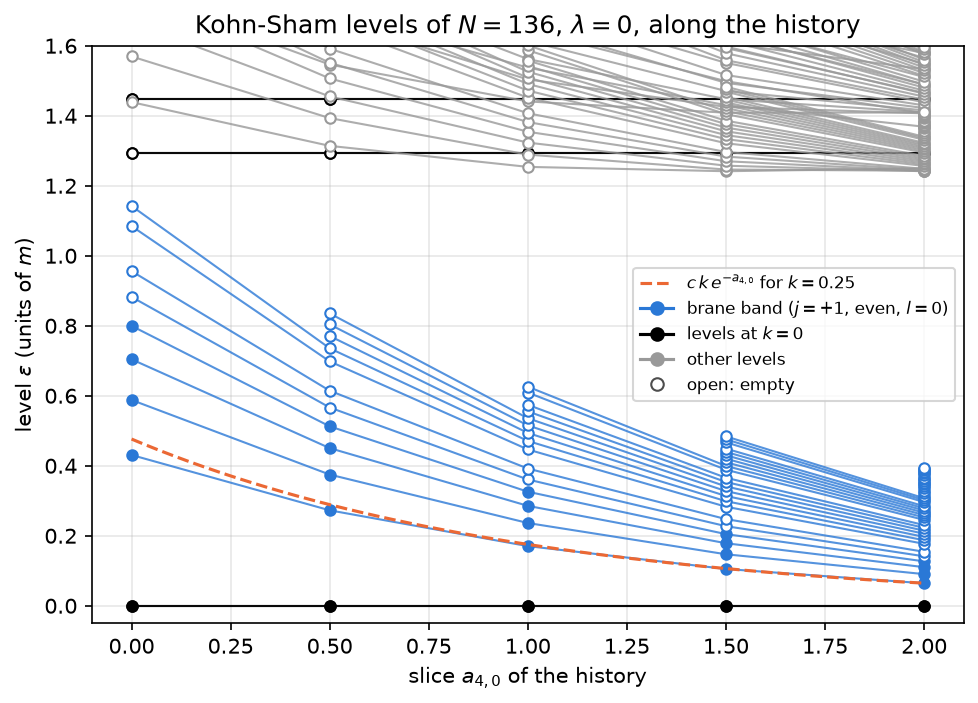

Figure 15a.1 saved as Revision/textbook/figures/15a_1_levels_history.png
RESULT number of brane-band levels followed through all five slices = 8
PASS the k = 0 levels are the same at every slice
PASS every brane-band level decreases strictly along the history


In [8]:
def read_levels(n, tag, a4):
    """{key: (eps, f)} of one state; key = (n2, j, parity, label)."""
    path = NEW_RESULTS / "ground/levels" / f"{state_id(n, tag, a4)}.csv"
    with open(path, newline="", encoding="utf-8") as handle:
        return {(int(r["n2"]), int(r["j"]), r["parity"], int(r["label"])):
                (float(r["eps"]), float(r["f"])) for r in csv.DictReader(handle)}


levels = [read_levels(136, "lam0", a4) for a4 in SLICES]  # one dictionary per slice
THEORY = json.loads(repository_file("Revision/kohn_sham/ks-theory.json").read_text(
    encoding="utf-8"))  # the theory file of the solver
C_SLOPE = float(THEORY["checksNumeric"]["braneBandSlope_M1_H1_L3_a0"])  # c
fig, ax = plt.subplots(figsize=(7.5, 5.0))
all_keys = sorted(set().union(*levels))
for key in all_keys:
    points = [(a4, lv[key]) for a4, lv in zip(SLICES, levels) if key in lv]
    xs = [p[0] for p in points]
    es = [p[1][0] for p in points]
    if min(es) > 1.6:
        continue  # only the part of the spectrum near the Fermi level
    band = key[1] == 1 and key[2] == "even" and key[3] == 0 and key[0] >= 1
    colour = PALETTE[0] if band else ("black" if key[0] == 0 else "0.6")
    ax.plot(xs, es, "-", color=colour, lw=1.0, alpha=0.8)
    for x, (e, f) in points:
        ax.plot([x], [e], "o", ms=5, color=colour,
                markerfacecolor=colour if f > 0.5 else "white")
a_fine = np.linspace(0.0, 2.0, 101)
ax.plot(a_fine, C_SLOPE * 0.25 * np.exp(-a_fine), "--", color=PALETTE[1], lw=1.5,
        label="$c\\,k\\,e^{-a_{4,0}}$ for $k = 0.25$")
ax.plot([], [], "o-", color=PALETTE[0], label="brane band ($j=+1$, even, $l=0$)")
ax.plot([], [], "o-", color="black", label="levels at $k = 0$")
ax.plot([], [], "o-", color="0.6", label="other levels")
ax.plot([], [], "o", color="0.3", markerfacecolor="white", label="open: empty")
ax.set_ylim(-0.05, 1.6)
ax.set_xlabel("slice $a_{4,0}$ of the history")
ax.set_ylabel("level $\\varepsilon$ (units of $m$)")
ax.set_title("Kohn-Sham levels of $N = 136$, $\\lambda = 0$, along the history")
ax.legend(fontsize=8, loc="center right")
save_figure(fig, "levels_history",
            "Kohn-Sham levels $\\varepsilon$ (vertical axis, units of $m$) of the "
            "state $N = 136$, $\\lambda = 0$ at the five slices $a_{4,0} = 0$ to $2$ "
            "(horizontal axis), each level followed by its key; filled dots are "
            "occupied, open dots empty. The brane band (blue) comes down as the "
            "3-momenta redshift like $k e^{-a_{4,0}}$, the dashed curve is the "
            "small-$k$ law for the first shell, and the levels at $k = 0$ (black) do "
            "not move.")
k0_keys = [key for key in levels[0] if key[0] == 0]
k0_spread = max(abs(lv[key][0] - levels[0][key][0]) for lv in levels for key in k0_keys)
band_keys = [key for key in all_keys if all(key in lv for lv in levels)
             and key[1] == 1 and key[2] == "even" and key[3] == 0 and key[0] >= 1]
decreasing = all(levels[i + 1][key][0] < levels[i][key][0]
                 for key in band_keys for i in range(4))
report("number of brane-band levels followed through all five slices", len(band_keys))
check(k0_spread <= 1e-12, "the k = 0 levels are the same at every slice")
check(decreasing, "every brane-band level decreases strictly along the history")

## 11. The gaps along the history

The next cell draws the Kohn-Sham gap of $N = 8$, $136$ and $688$ (without
interaction) against the slice on a logarithmic vertical axis, together with dashed
lines proportional to $e^{-a_{4,0}}$ through the first point of each curve. Every gap
shrinks along the history, somewhat more slowly than $e^{-a_{4,0}}$: the gap is the
distance between two brane-band levels (for $N = 688$ at $a_{4,0} = 0$ between a band
level and the bulk level at $k = 0$), and the band levels approach the straight line
$c\,k\,e^{-a_{4,0}}$ only when the redshifted momenta $k e^{-a_{4,0}}$ are small.
Without interaction the levels do not change when one particle is
moved, so the Delta-SCF energy must equal the gap exactly; the solver recorded this
as its check `excited_delta_scf_free_equals_gap`.

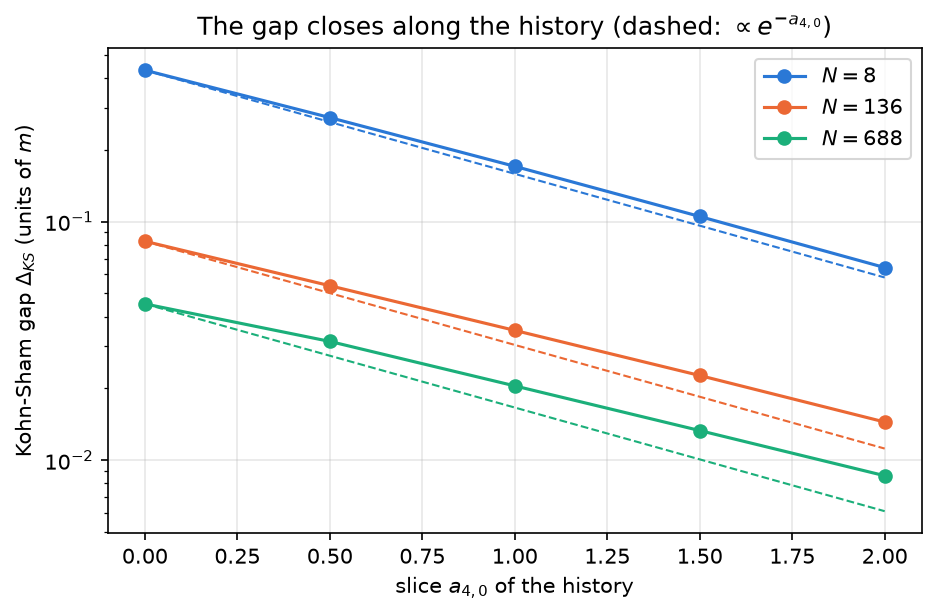

Figure 15a.2 saved as Revision/textbook/figures/15a_2_gaps_history.png
RESULT largest |Delta-SCF - gap| without interaction = 2.0e-11
PASS Delta-SCF equals the gap without interaction
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    excited_delta_scf_free_equals_gap
PASS every gap shrinks from slice to slice


In [9]:
fig, ax = plt.subplots()
for colour, n in zip(PALETTE, (8, 136, 688)):
    gaps = [float(ground[state_id(n, "lam0", a4)]["KS_gap"]) for a4 in SLICES]
    ax.plot(SLICES, gaps, "o-", color=colour, lw=1.5, label=f"$N = {n}$")
    ax.plot(a_fine, gaps[0] * np.exp(-a_fine), "--", color=colour, lw=1.0)
ax.set_yscale("log")
ax.set_xlabel("slice $a_{4,0}$ of the history")
ax.set_ylabel("Kohn-Sham gap $\\Delta_{KS}$ (units of $m$)")
ax.set_title("The gap closes along the history (dashed: $\\propto e^{-a_{4,0}}$)")
ax.legend()
save_figure(fig, "gaps_history",
            "Kohn-Sham gap $\\Delta_{KS}$ (vertical axis, logarithmic, units of $m$) "
            "of the states $N = 8$, $136$ and $688$ without interaction at the five "
            "slices $a_{4,0}$ (horizontal axis). Dashed lines fall like "
            "$e^{-a_{4,0}}$ from the first point of each curve: every gap shrinks "
            "along the history, somewhat more slowly than this, because the levels "
            "that bound it belong to the brane band, whose momenta redshift like "
            "$k e^{-a_{4,0}}$ but whose energy is linear in the momentum only for "
            "small momenta.")
free_dscf = max(abs(float(excited[state_id(n, "lam0", a)]["delta_SCF_minus_gap"]))
                for n in (8, 136, 688) for a in SLICES)
report("largest |Delta-SCF - gap| without interaction", f"{free_dscf:.1e}")
check(free_dscf <= 1e-10, "Delta-SCF equals the gap without interaction",
      record=f"{RECORD_REPORT}, check excited_delta_scf_free_equals_gap")
shrinking = all(float(ground[state_id(n, "lam0", SLICES[i + 1])]["KS_gap"])
                < float(ground[state_id(n, "lam0", SLICES[i])]["KS_gap"])
                for n in (8, 136, 688) for i in range(4))
check(shrinking, "every gap shrinks from slice to slice")

With interaction the orbitals relax when a particle is moved, and Delta-SCF differs
from the gap. The next cell draws the difference $\Delta_{SCF} - \Delta_{KS}$ for
the four couplings $\pm\lambda_1$, $\pm\lambda_2$ and the three particle numbers. The
vertical axis is *symmetric logarithmic*: logarithmic for large positive and
negative values and linear near zero (between $-10^{-9}$ and $10^{-9}$), so values of
both signs and very different sizes fit on one axis.

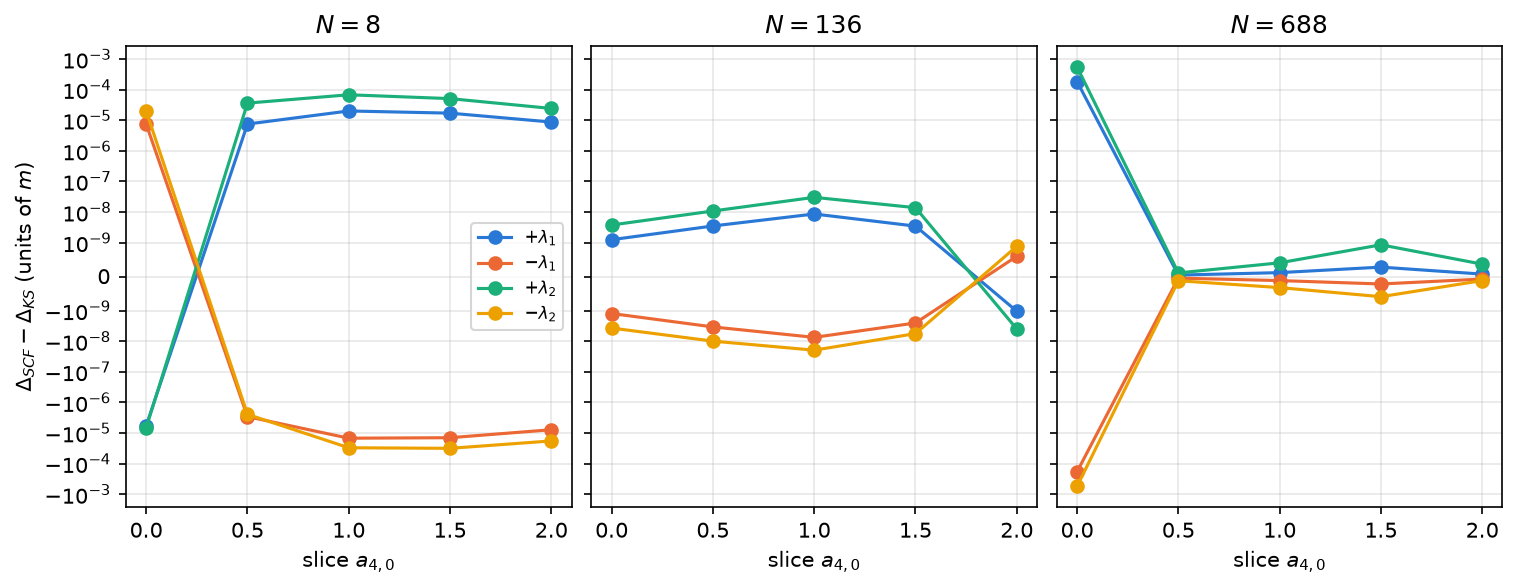

Figure 15a.3 saved as Revision/textbook/figures/15a_3_delta_scf.png
RESULT largest |Delta-SCF - gap| over the 75 states = 5.496e-04
PASS the orbital relaxation is below 0.001 m in every state


In [10]:
fig, axes = plt.subplots(1, 3, figsize=(10.0, 3.8), sharey=True,
                         layout="constrained")
for ax, n in zip(axes, (8, 136, 688)):
    for colour, tag, label in zip(PALETTE, ("lamp1", "lamm1", "lamp2", "lamm2"),
                                  ("$+\\lambda_1$", "$-\\lambda_1$", "$+\\lambda_2$",
                                   "$-\\lambda_2$")):
        diff = [float(excited[state_id(n, tag, a)]["delta_SCF_minus_gap"])
                for a in SLICES]
        ax.plot(SLICES, diff, "o-", color=colour, lw=1.5, label=label)
    ax.set_yscale("symlog", linthresh=1e-9)
    ax.set_title(f"$N = {n}$")
    ax.set_xlabel("slice $a_{4,0}$")
axes[0].set_ylabel("$\\Delta_{SCF} - \\Delta_{KS}$ (units of $m$)")
axes[0].legend(fontsize=8)
save_figure(fig, "delta_scf",
            "Orbital relaxation: the Delta-SCF excitation energy minus the Kohn-Sham "
            "gap (vertical axis, symmetric logarithmic, units of $m$) for the "
            "couplings $\\pm\\lambda_1$ and $\\pm\\lambda_2$ at the five slices "
            "(horizontal axis), for $N = 8$, $136$ and $688$. It is small everywhere; "
            "it is largest, about $5 \\times 10^{-4}$, for $N = 688$ at "
            "$a_{4,0} = 0$, where the lowest empty level is a bulk level at $k = 0$.")
largest_relax = max(abs(float(excited[i]["delta_SCF_minus_gap"])) for i in excited)
report("largest |Delta-SCF - gap| over the 75 states", f"{largest_relax:.3e}")
check(largest_relax < 1e-3, "the orbital relaxation is below 0.001 m in every state")

## 12. The total energy along the history

The next cell draws $E_{KS}$ of $N = 136$ and $688$ without interaction (left) and
the change of $E_{KS}$ caused by the interaction, $E_{KS}(\lambda) - E_{KS}(0)$, for
$N = 136$ (right). The energy of the gas falls along the history because the brane
band redshifts. A repulsive coupling ($\lambda > 0$) raises the energy and an
attractive one lowers it, for $N = 136$ and $N = 688$; the check confirms this order
at every slice. (For $N = 8$ the order is reversed: the eight zero modes have no
scalar density $S$, so to first order in $\lambda$ the only interaction energy is
the exchange term $-\tfrac{1}{32}\lambda n^2$, which is negative for $\lambda > 0$.)

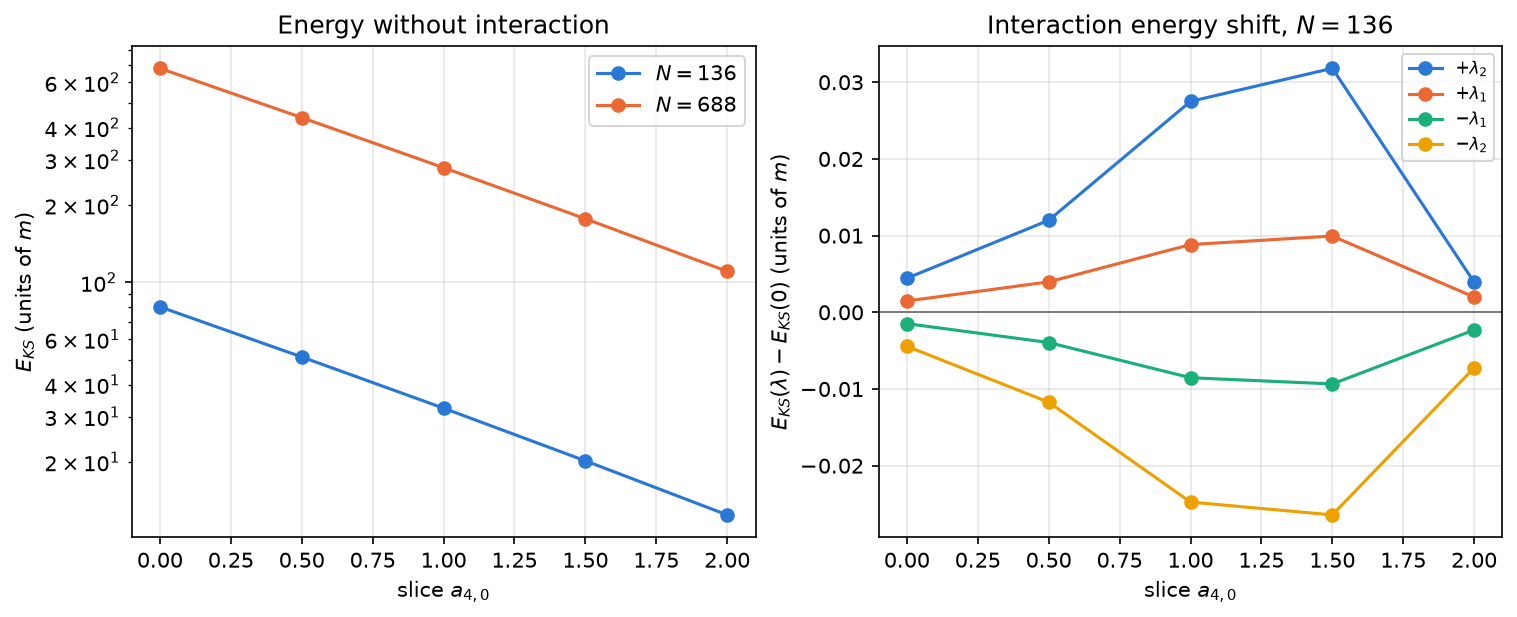

Figure 15a.4 saved as Revision/textbook/figures/15a_4_energy_history.png
PASS E(+lambda2) > E(+lambda1) > E(0) > E(-lambda1) > E(-lambda2), N = 136 and 688
PASS the energy of N = 136 and 688 falls from slice to slice


In [11]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
for colour, n in zip(PALETTE, (136, 688)):
    energies = [float(ground[state_id(n, "lam0", a)]["E_KS"]) for a in SLICES]
    left.plot(SLICES, energies, "o-", color=colour, lw=1.5, label=f"$N = {n}$")
left.set_yscale("log")
left.set_xlabel("slice $a_{4,0}$")
left.set_ylabel("$E_{KS}$ (units of $m$)")
left.set_title("Energy without interaction")
left.legend()
tags = ("lamp2", "lamp1", "lamm1", "lamm2")
labels = ("$+\\lambda_2$", "$+\\lambda_1$", "$-\\lambda_1$", "$-\\lambda_2$")
for colour, tag, label in zip(PALETTE, tags, labels):
    shift = [float(ground[state_id(136, tag, a)]["E_KS"])
             - float(ground[state_id(136, "lam0", a)]["E_KS"]) for a in SLICES]
    right.plot(SLICES, shift, "o-", color=colour, lw=1.5, label=label)
right.axhline(0.0, color="0.4", lw=0.8)
right.set_xlabel("slice $a_{4,0}$")
right.set_ylabel("$E_{KS}(\\lambda) - E_{KS}(0)$ (units of $m$)")
right.set_title("Interaction energy shift, $N = 136$")
right.legend(fontsize=8)
save_figure(fig, "energy_history",
            "Left: the Kohn-Sham energy $E_{KS}$ (vertical axis, logarithmic, units "
            "of $m$) of $N = 136$ and $N = 688$ without interaction at the five "
            "slices; it falls along the history as the brane band redshifts. Right: "
            "the energy shift caused by the couplings $\\pm\\lambda_1$ and "
            "$\\pm\\lambda_2$ for $N = 136$ (vertical axis, units of $m$): repulsion "
            "raises and attraction lowers the energy, by at most $0.032\\,m$ out of "
            "$12$ to $80\\,m$.")
ordered = all(
    float(ground[state_id(n, "lamp2", a)]["E_KS"])
    > float(ground[state_id(n, "lamp1", a)]["E_KS"])
    > float(ground[state_id(n, "lam0", a)]["E_KS"])
    > float(ground[state_id(n, "lamm1", a)]["E_KS"])
    > float(ground[state_id(n, "lamm2", a)]["E_KS"])
    for n in (136, 688) for a in SLICES)
check(ordered, "E(+lambda2) > E(+lambda1) > E(0) > E(-lambda1) > E(-lambda2), "
               "N = 136 and 688")
falling = all(float(ground[state_id(n, "lam0", SLICES[i + 1])]["E_KS"])
              < float(ground[state_id(n, "lam0", SLICES[i])]["E_KS"])
              for n in (136, 688) for i in range(4))
check(falling, "the energy of N = 136 and 688 falls from slice to slice")

## 13. Where the particles are: the densities

The solver writes for every ground state the **profiles**: the densities and the
energy-momentum tensor at the 151 points $y = -3, -2.98, \dots, 0$. The next cell
reads the proper number density $n(y)$ of $N = 136$ without interaction at the
slices $0$, $1$ and $2$ and draws it (left, logarithmic) together with the number of
particles per unit of $y$, $2\,\mathrm{Vol}_7\, e^{6Hy} n(y)$ (right), where
$\mathrm{Vol}_7 = (2\pi/\Delta k)^3$ is the proper 7-volume of the box per unit of
$e^{6Hy}$. The proper density is largest at the tip (the proper volume
$e^{6Hy}$ is tiny there), but the particles themselves sit near the brane; along the
history they spread toward the tip.

The integral of the right-hand curve over $y$ must be $N = 136$. It is computed with
**Simpson's rule** on the 151 points (step $h = 0.02$): $\int f\,dy \approx
\tfrac{h}{3}(f_0 + 4 f_1 + 2 f_2 + 4 f_3 + \dots + 4 f_{149} + f_{150})$.

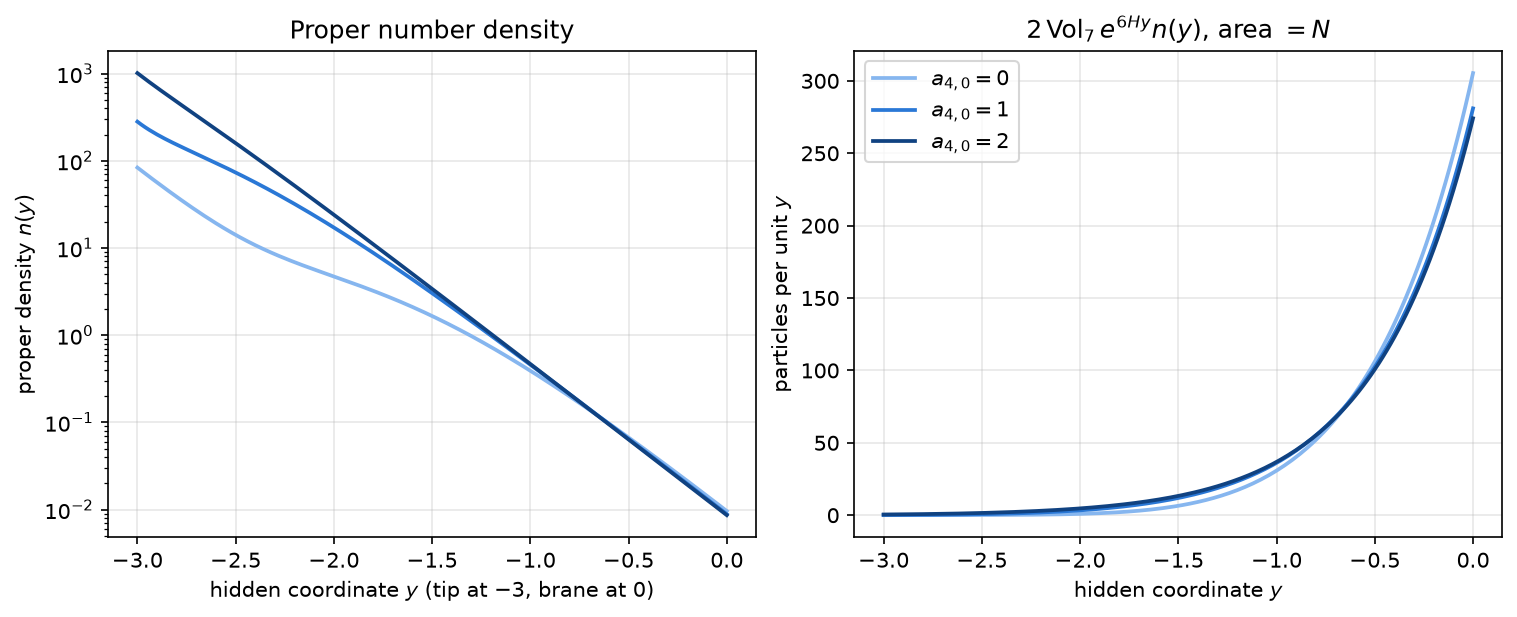

Figure 15a.5 saved as Revision/textbook/figures/15a_5_densities.png
RESULT particle number from the profiles at a4,0 = 0, 1, 2 = 136.000002, 136.000002,
    136.000002
PASS Simpson's rule on the profiles gives N = 136 at every slice
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    ground_N_conservation


In [12]:
VOL7 = (2.0 * math.pi / 0.25) ** 3  # proper 7-volume per unit e^{6Hy} (v_t = 1)


def read_profile(n, tag, a4):
    """The profile table of one state as a dictionary column -> numpy array."""
    path = NEW_RESULTS / "ground/profiles" / f"{state_id(n, tag, a4)}.csv"
    data = np.genfromtxt(path, delimiter=",", names=True)
    return {name: data[name] for name in data.dtype.names}


def simpson(values, step):
    """Simpson's rule for equally spaced values (an odd number of points)."""
    weights = np.full(len(values), 2.0)
    weights[1::2] = 4.0
    weights[0] = weights[-1] = 1.0
    return step / 3.0 * float(np.sum(weights * values))


fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
counts = []
for shade, a4 in zip((SLICE_SHADES[0], SLICE_SHADES[2], SLICE_SHADES[4]), (0, 1, 2)):
    prof = read_profile(136, "lam0", a4)
    y = prof["y"]
    per_y = 2.0 * VOL7 * np.exp(6.0 * y) * prof["n"]  # particles per unit y
    counts.append(simpson(per_y, y[1] - y[0]))
    left.plot(y, prof["n"], color=shade, lw=1.8, label=f"$a_{{4,0}} = {a4}$")
    right.plot(y, per_y, color=shade, lw=1.8, label=f"$a_{{4,0}} = {a4}$")
left.set_yscale("log")
left.set_xlabel("hidden coordinate $y$ (tip at $-3$, brane at $0$)")
left.set_ylabel("proper density $n(y)$")
left.set_title("Proper number density")
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("particles per unit $y$")
right.set_title("$2\\,\\mathrm{Vol}_7\\, e^{6Hy} n(y)$, area $= N$")
right.legend()
save_figure(fig, "densities",
            "Left: the proper number density $n(y)$ (vertical axis, logarithmic, "
            "particles per unit proper 7-volume) of $N = 136$ without interaction "
            "at $a_{4,0} = 0$, $1$, $2$ against the hidden coordinate $y$ (horizontal "
            "axis). Right: the particles per unit $y$, "
            "$2\\,\\mathrm{Vol}_7 e^{6Hy} n(y)$, whose area is $N = 136$. The particles "
            "sit near the brane $y = 0$ and spread toward the tip along the history; "
            "the proper density is largest at the tip, where the proper volume is "
            "small.")
report("particle number from the profiles at a4,0 = 0, 1, 2",
       ", ".join(f"{c:.6f}" for c in counts))
check(max(abs(c - 136.0) for c in counts) < 1e-5,
      "Simpson's rule on the profiles gives N = 136 at every slice",
      record=f"{RECORD_REPORT}, check ground_N_conservation")

## 14. The self-consistent potentials

With interaction the effective mass $M(y) = m + \tfrac{15}{16}\lambda S(y)$ and the
potential $v(y) = -\tfrac{1}{16}\lambda n(y)$ differ from $m$ and $0$. The next cell
draws $M - m$ and $v$ for $N = 136$ with the repulsive coupling $+\lambda_2$ at the
five slices. Both are largest in the tip region and grow along the history,
because the redshifted brane-band orbitals spread toward the tip, where the proper
densities are large. This is why the couplings were calibrated over the whole
history (so that the first-order potential stays below $0.3\,m$ at every slice).
The check compares, for each slice, the largest $|M - m|$ on the 151 profile points
with the value `max_abs_Meff_minus_m` that the solver recorded on its fine grid of
1801 points (every profile point is also a point of the fine grid): the profile
value cannot be larger, and since the maximum lies between two profile points it
is smaller by a little, at most 0.2 percent.

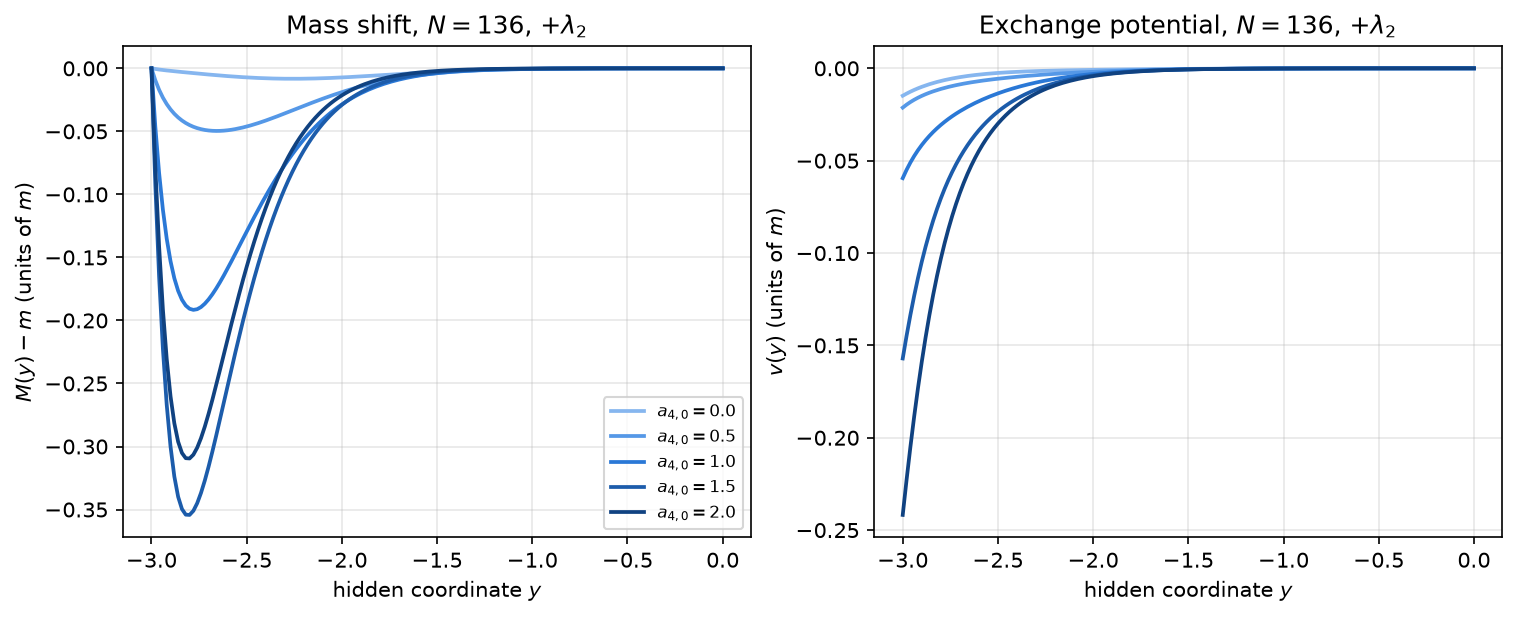

Figure 15a.6 saved as Revision/textbook/figures/15a_6_potentials.png
RESULT profile maximum / recorded maximum of |M - m| = 0.99997, 0.99996, 0.99997,
    0.99893, 0.99891
PASS the profile maxima of |M - m| lie within 0.2 percent below the recorded ones
     reproduces Revision/kohn_sham/results/ground/summary.csv, column
    max_abs_Meff_minus_m


In [13]:
fig, (left, right) = plt.subplots(1, 2, figsize=(10.0, 4.0), layout="constrained")
ratios = []  # profile maximum / recorded maximum, one per slice
for shade, a4 in zip(SLICE_SHADES, SLICES):
    prof = read_profile(136, "lamp2", a4)
    left.plot(prof["y"], prof["M_eff"] - 1.0, color=shade, lw=1.8,
              label=f"$a_{{4,0}} = {a4}$")
    right.plot(prof["y"], prof["v_v"], color=shade, lw=1.8)
    recorded = float(ground[state_id(136, "lamp2", a4)]["max_abs_Meff_minus_m"])
    ratios.append(float(np.max(np.abs(prof["M_eff"] - 1.0))) / recorded)
left.set_xlabel("hidden coordinate $y$")
left.set_ylabel("$M(y) - m$ (units of $m$)")
left.set_title("Mass shift, $N = 136$, $+\\lambda_2$")
left.legend(fontsize=8)
right.set_xlabel("hidden coordinate $y$")
right.set_ylabel("$v(y)$ (units of $m$)")
right.set_title("Exchange potential, $N = 136$, $+\\lambda_2$")
save_figure(fig, "potentials",
            "The self-consistent mass shift $M(y) - m$ (left) and potential $v(y)$ "
            "(right), vertical axes in units of $m$, of $N = 136$ with the repulsive "
            "coupling $+\\lambda_2$ at the five slices (light blue: $a_{4,0} = 0$, "
            "dark blue: $a_{4,0} = 2$) against the hidden coordinate $y$. Both are "
            "concentrated in the tip region and grow along the history, but stay "
            "below about $0.4\\,m$.")
report("profile maximum / recorded maximum of |M - m|",
       ", ".join(f"{r:.5f}" for r in ratios))
check(all(0.998 <= r <= 1.0 + 1e-12 for r in ratios),
      "the profile maxima of |M - m| lie within 0.2 percent below the recorded ones",
      record=f"{RECORD_RESULTS}/ground/summary.csv, column max_abs_Meff_minus_m")

## 15. How fast the self-consistent loop converges

The file `ground/runs.json` records for every ground state the residual of each
iteration of the self-consistent loop. The next cell draws it for the strongest
couplings $\pm\lambda_2$ at the last slice $a_{4,0} = 2$ (the hardest cases), with
the tolerance $10^{-11}$ as a dashed line, and checks that all 75 ground states
converged directly (path `direct`: no fallback was needed) with a final residual at
or below the tolerance (zero for $\lambda = 0$, where one iteration suffices).

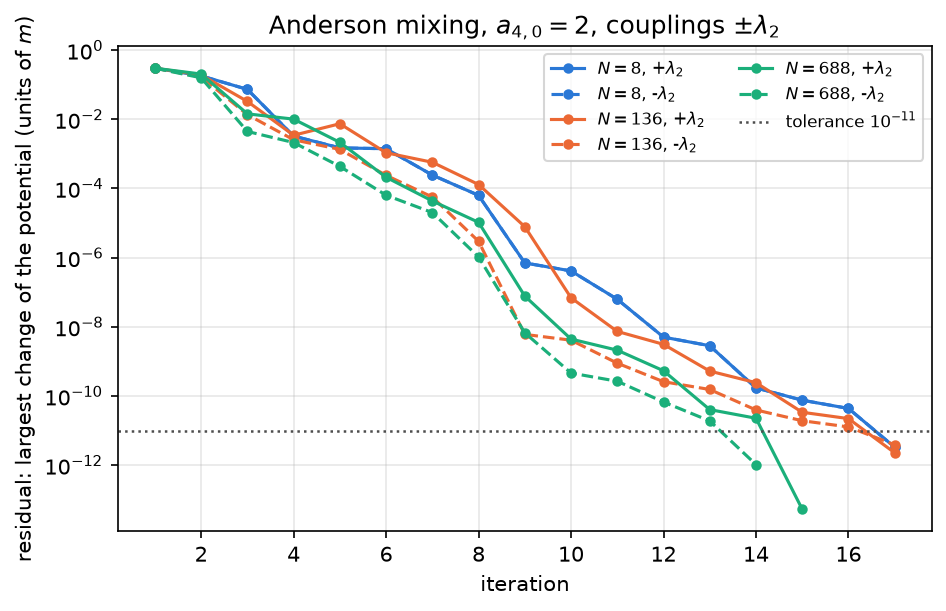

Figure 15a.7 saved as Revision/textbook/figures/15a_7_scf_convergence.png
RESULT largest final residual / largest number of iterations = 9.34e-12 / 17
PASS all 75 ground states converged directly below the tolerance 1e-11
     reproduces Revision/kohn_sham/reports/ks-rust-solver.json, check
    ground_scf_converged


In [14]:
runs = json.loads((NEW_RESULTS / "ground/runs.json").read_text(encoding="utf-8"))
by_id = {run["id"]: run for run in runs}
fig, ax = plt.subplots()
styles = {"lamp2": "-", "lamm2": "--"}
for colour, n in zip(PALETTE, (8, 136, 688)):
    for tag, style in styles.items():
        history = by_id[state_id(n, tag, 2.0)]["scfHistory_iteration_residual_E"]
        ax.plot([h[0] for h in history], [h[1] for h in history], style, marker="o",
                ms=4, color=colour, lw=1.5,
                label=f"$N = {n}$, {'+' if tag == 'lamp2' else '-'}$\\lambda_2$")
ax.axhline(1e-11, color="0.3", ls=":", lw=1.2, label="tolerance $10^{-11}$")
ax.set_yscale("log")
ax.set_xlabel("iteration")
ax.set_ylabel("residual: largest change of the potential (units of $m$)")
ax.set_title("Anderson mixing, $a_{4,0} = 2$, couplings $\\pm\\lambda_2$")
ax.legend(fontsize=8, ncol=2)
save_figure(fig, "scf_convergence",
            "Convergence of the self-consistent loop with Anderson mixing: the "
            "residual (vertical axis, logarithmic, units of $m$) at each iteration "
            "(horizontal axis) for $N = 8$, $136$, $688$ with the couplings "
            "$+\\lambda_2$ (solid) and $-\\lambda_2$ (dashed) at $a_{4,0} = 2$; the "
            "dotted line is the tolerance $10^{-11}$. The residual falls by about one "
            "order of magnitude per iteration, and every loop ends below the "
            "tolerance after at most 17 iterations. For $N = 8$ the curves of "
            "$+\\lambda_2$ and $-\\lambda_2$ coincide, a consequence of an exact "
            "symmetry of the zero-mode state.")
direct = all(run["path"] == "direct" for run in runs)
final = max(run["scfHistory_iteration_residual_E"][-1][1] for run in runs)
longest = max(run["iterations"] for run in runs)
report("largest final residual / largest number of iterations",
       f"{final:.2e} / {longest}")
check(len(runs) == 75 and direct and final <= 1e-11,
      "all 75 ground states converged directly below the tolerance 1e-11",
      record=f"{RECORD_REPORT}, check ground_scf_converged")

## 16. The last check

The last cell checks that every figure file of this notebook exists in the folder
Revision/textbook/figures and prints the number of checks that passed.

In [15]:
NAMES = ["levels_history", "gaps_history", "delta_scf", "energy_history",
         "densities", "potentials", "scf_convergence"]  # the figures, in order
missing = [name for number, name in enumerate(NAMES, start=1)
           if not output_file(f"{FIGURE_FOLDER}/15a_{number}_{name}.png").is_file()]
check(missing == [], "every figure file of this notebook exists")
all_checks_passed()

PASS every figure file of this notebook exists
ALL 20 CHECKS PASSED (notebook 15a)


## 17. What this notebook showed

- The Rust solver, built on this computer, reproduces the whole canonical matrix of
  the Revision record: the same files, all 42 of its own checks PASS, and every key
  number within the tolerances fixed in advance (COMPUTED).
- Along the deflating history the brane band redshifts like $k e^{-a_{4,0}}$, the
  levels at $k = 0$ stay where they are, the gaps close at nearly the rate
  $e^{-a_{4,0}}$, and the energy of the gas falls.
- Without interaction Delta-SCF equals the gap exactly; with interaction the orbital
  relaxation stays below $10^{-3}\,m$.
- The particles sit near the brane, the proper densities and the self-consistent
  potentials are largest at the tip, and the self-consistent loop converges in at
  most 17 iterations.
- These are instantaneous states on a PRESCRIBED background; the brane is ASSUMED;
  the filling is a CONVENTION; whether the gas really follows the instantaneous
  states along the history is the question of adiabaticity, which the solver
  measures with the number $Q_{max}$ compared above.